In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_summary_results_run_sisepuede_run_2025-08-10t10;29;30.545790")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.2.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,59.720047,3553.270010,-42.336438
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,30.972144,3028.607700,-21.656242
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,92.551550,4127.536839,-40.157702
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,11.015231,2668.240547,-53.155978
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,41.876734,3343.173022,-77.798140


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if "emission" in col] + ["technical_cost"]
target_cols

['emission_avg_last_five_years', 'emission_total', 'technical_cost']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_frac_enfu_transmission_loss_fuel_electricity',
 'group_6_nemomod_en',
 'group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis',
 'group_8_frac_fgtv_reduction_in_fugitive_leaks',
 'group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_10_efficfactor_enfu_industrial_energy_fuel',
 'group_11_scalar_inen_energy_demand',
 'group_12_frac_inen_energy',
 'group_13_frac_ippu_cement_clinker',
 'group_14_ef_ippu_tonne_c',
 'group_15_ef_ippu_tonne_n2o_per',
 'group_16_ef_ippu_tonne_c',
 'group_17_pij_lndu',
 'group_18_frac_lndu_improved_pastures',
 'group_19_lndu_reallocation_factor',
 'group_20_gasrf_lsmm_biogas_anaerobic',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm',
 'group_23_frac_lvst_mm_chickens',
 'group_24_ef_lvst_entferm',
 'group_25_frac_gnrl_eating_red_meat

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,1988.000000,1988.000000,1.988000e+03
mean,104.749732,4266.429562,-2.349160e+08
std,218.886143,3463.127200,1.116284e+09
min,-16.071475,1726.857850,-5.640888e+09
25%,34.913576,3145.931248,-9.072551e+01
50%,53.564501,3457.359997,-5.024862e+01
75%,72.663746,3798.960870,-2.025542e+01
max,1524.495400,26664.633567,4.216979e+02


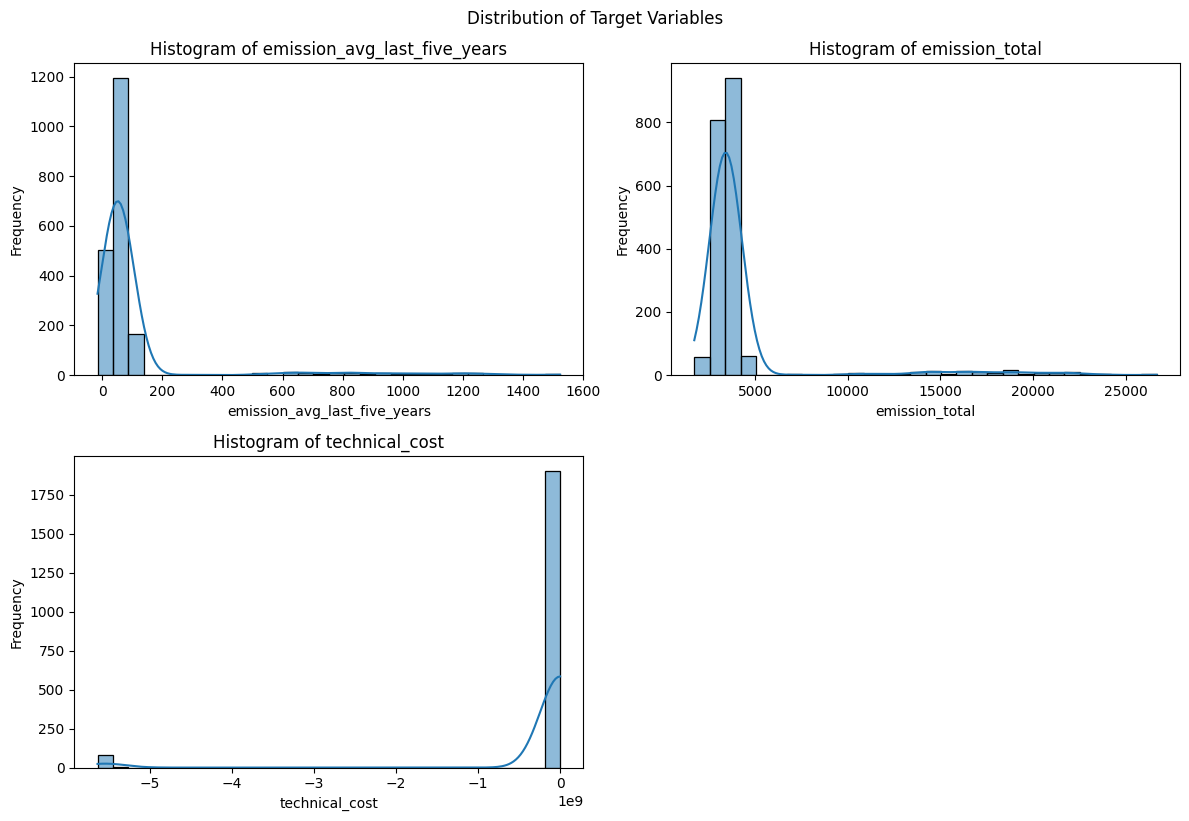

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [10]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9894
technical_cost                 : 0.7751
group_6_nemomod_en             : 0.1412
group_44_frac_waso             : 0.1016


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9894
technical_cost                 : 0.7770
group_6_nemomod_en             : 0.1265


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_avg_last_five_years   : 0.7770
emission_total                 : 0.7751



In [11]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [ ]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 6.54, 'emission_total': 6.84, 'technical_cost': 7.04}


## Data Cleaning

In [13]:
dcu = DataCleaningUtils()

In [14]:
training_df.shape

(1988, 61)

In [15]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [16]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [17]:
training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (1844, 61)


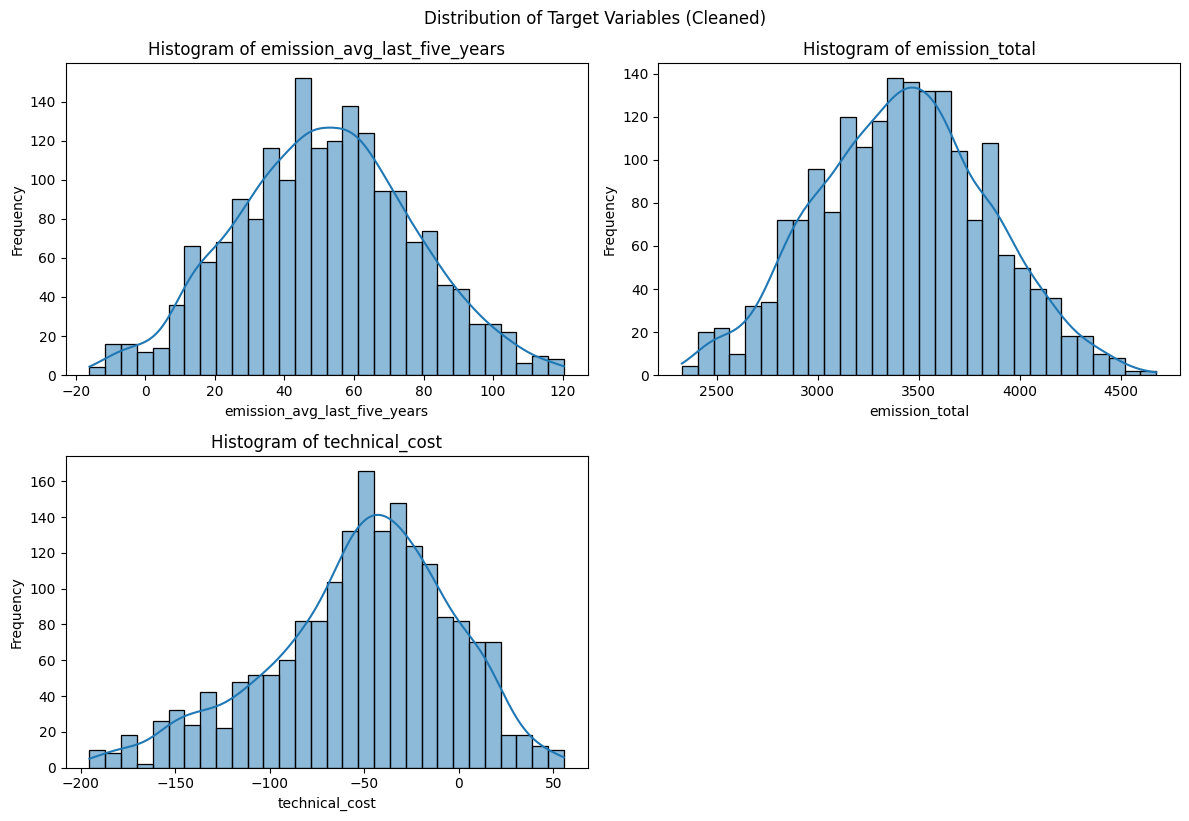

In [18]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [21]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [22]:
edau.get_target_var_corr(training_df_cleaned, "emission_total")
edau.get_target_var_corr(training_df_cleaned, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9871
group_6_nemomod_en             : 0.7272
group_12_frac_inen_energy      : 0.5282
technical_cost                 : 0.2899
group_26_frac_ippu_production_with_co2_capture : 0.2033
group_51_exports_enfu_pj_fuel  : 0.1552
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.1478
group_34_fuelefficiency_trns   : 0.1362
group_11_scalar_inen_energy_demand : 0.1361
group_36_frac_trns_fuelmix_road_light : 0.1131
group_38_frac_trns_fuelmix     : 0.1061
group_10_efficfactor_enfu_industrial_energy_fuel : 0.1059


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9871
group_6_nemomod_en             : 0.6423
group_12_frac_inen_energ

In [23]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,1844.000000,1844.000000,1844.000000
mean,51.393465,3419.916266,-52.062070
std,25.446997,423.524762,48.198407
min,-16.071475,2327.925268,-195.391414
25%,34.049420,3134.720584,-79.868385
50%,51.468450,3425.230378,-46.457245
75%,69.017881,3696.380616,-18.257018
max,120.356950,4674.973567,55.520017


In [24]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [25]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [26]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [27]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [28]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB ===
emission_total                
  Train → MAE: 0.1232, RMSE: 0.1914, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 31.0946, RMSE: 79.2472, R²: 0.9672, SMAPE: 0.9%
emission_avg_last_five_years  
  Train → MAE: 0.0092, RMSE: 0.0142, R²: 1.0000, SMAPE: 0.1%
   Test → MAE: 2.2500, RMSE: 5.7018, R²: 0.9526, SMAPE: 4.7%
technical_cost                
  Train → MAE: 0.0322, RMSE: 0.0489, R²: 1.0000, SMAPE: 0.4%
   Test → MAE: 3.8852, RMSE: 10.1342, R²: 0.9577, SMAPE: 9.3%

=== MeanBaseline ===
emission_total                
  Train → MAE: 337.5692, RMSE: 419.5880, R²: 0.0000, SMAPE: 10.0%
   Test → MAE: 354.7087, RMSE: 438.5262, R²: -0.0039, SMAPE: 10.4%
emission_avg_last_five_years  
  Train → MAE: 20.2808, RMSE: 25.2401, R²: 0.0000, SMAPE: 44.0%
   Test → MAE: 21.2108, RMSE: 26.2318, R²: -0.0028, SMAPE: 45.1%
technical_cost                
  Train → MAE: 37.6133, RMSE: 47.8961, R²: 0.0000, SMAPE: 77.1%
   Test → MAE: 38.9377, RMSE: 49.3380, R²: -0.0027, SMAPE: 78.1%

=== MedianBaseline

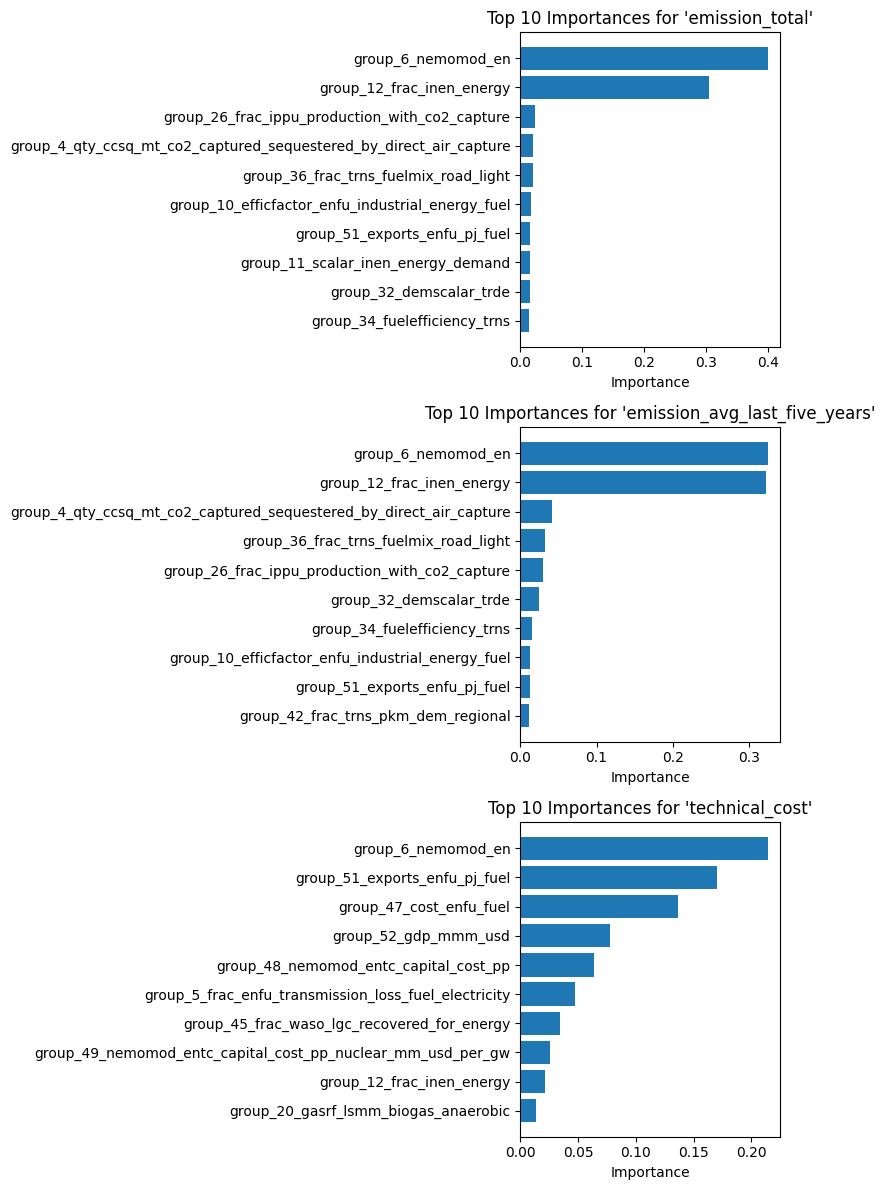

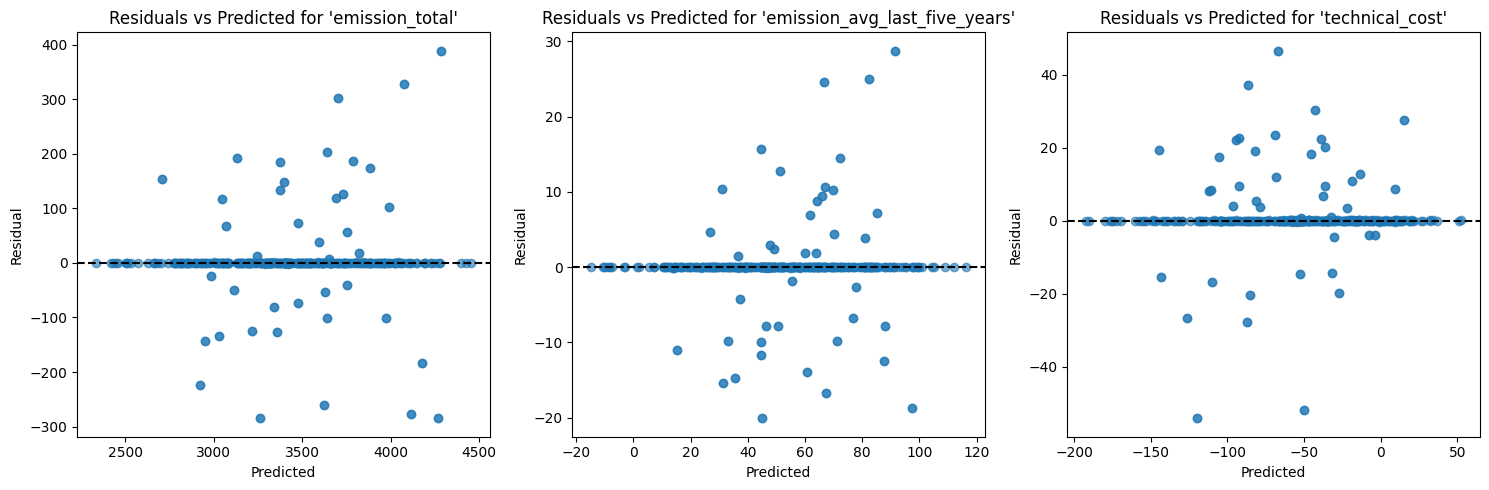

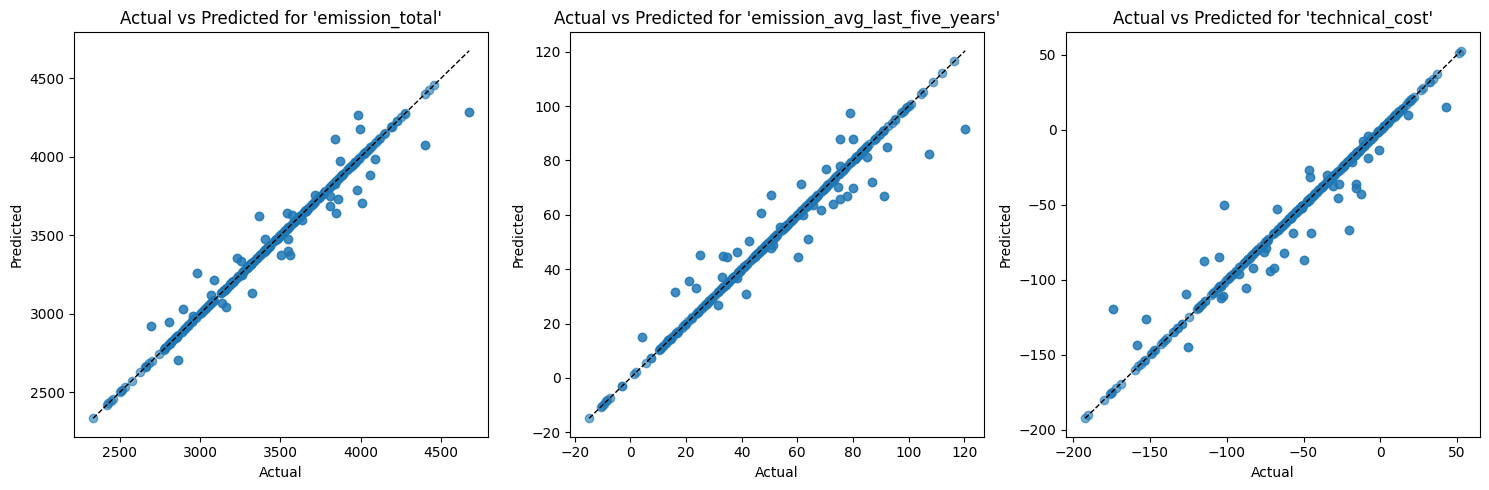

In [29]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years", "technical_cost"])
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [30]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,59.720047,3553.270010,-42.336438
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,30.972144,3028.607700,-21.656242
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,92.551550,4127.536839,-40.157702
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,11.015231,2668.240547,-53.155978
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,41.876734,3343.173022,-77.798140


In [31]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [32]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3553.195312                     59.724808      -42.336052


In [36]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.2.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.2.pkl to /Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.2.pkl.


In [37]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [38]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3553.195312                     59.724808      -42.336052
